# **Question 3:**

In [1]:
import numpy as np
import matplotlib.pyplot as plt


In [2]:
# read displacement data from file of stepsize= 0.03125 and store in a list and make different list for velocity for the same stepsize
# Define the file name
filename = "resultsq3/output_RK4_0.031250.txt"

# Initialize lists to store displacement and velocity data
displacements = []
velocities = []

# Open the file and read the data
with open(filename, 'r') as file:
    # Skip the header line
    next(file)
    
    # Read the data line by line
    for line in file:
        # Split the line into components
        parts = line.split()
        
        # Extract the displacement and velocity values
        displacement = float(parts[1])
        velocity = float(parts[2])
        
        # Store the values in the respective lists
        displacements.append(displacement)
        velocities.append(velocity)

# Print the lists to verify the data
# print("Displacements:", displacements)
# print("Velocities:", velocities)
  

In [3]:
# Create the folder to store the plots named figures in the current directory q3
import os
if not os.path.exists("figures"):
    os.makedirs("figures")

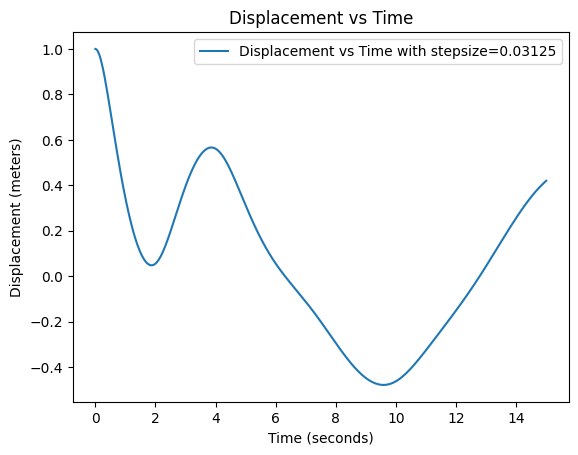

In [4]:
# Plot the displacement data
t = np.arange(0, 15+0.03125, 0.03125)
plt.plot(t, displacements, label='Displacement vs Time with stepsize=0.03125')
plt.xlabel('Time (seconds)')
plt.ylabel('Displacement (meters)')
plt.title('Displacement vs Time')
plt.legend()
# Save the plot to a file
plt.savefig('figures/displacement_plot_0.03125.png')
plt.show()


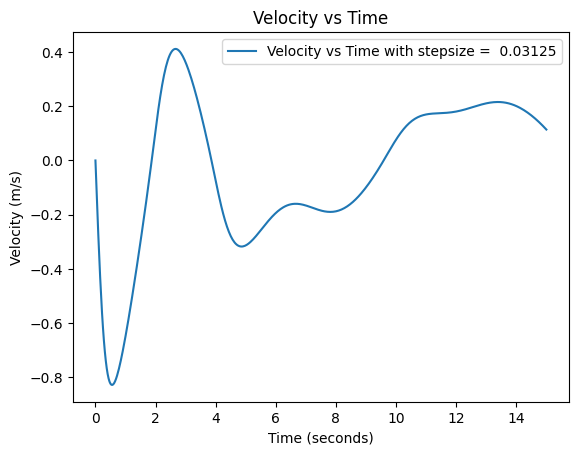

In [5]:
# Plot the velocity data
plt.plot(t, velocities, label='Velocity vs Time with stepsize =  0.03125')
plt.xlabel('Time (seconds)')
plt.ylabel('Velocity (m/s)')
plt.title('Velocity vs Time')   
plt.legend()
# Save the plot to a file
plt.savefig('figures/velocity_plot_0.03125.png')
plt.show()

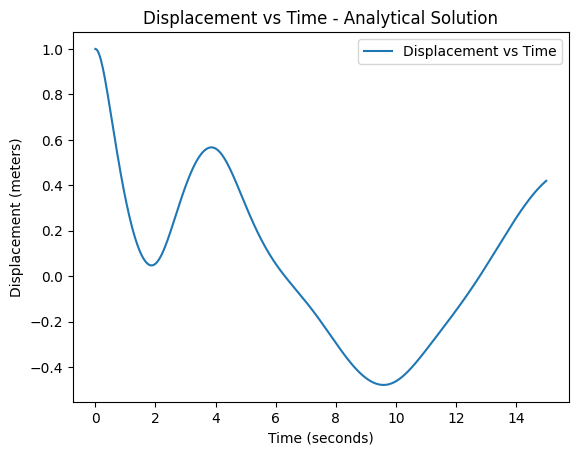

In [6]:
from scipy.integrate import solve_ivp
m= 2
a= 5
k= 6
f_0= 2.5
w= 0.5

# define the non-linear system of ODEs
def nonlinear_system(m, a, k, f_0, w):
    def system(t, state):
        x, v = state
        dxdt = v
        dvdt = (f_0*np.sin(w*t) - a*abs(v)*v - k*x)/m
        return [dxdt, dvdt]
    return system

# Define the initial conditions
x0 , v0 = 1, 0
t_span = (0, 15) # time span for the simulation which is a tuple
t_eval = np.arange(0, 15+0.03125, 0.03125) # time points where the solution is computed
system = nonlinear_system(m, a, k, f_0, w)
solution = solve_ivp(system, t_span, [x0, v0], t_eval=t_eval)
# Extract the displacement and velocity data
displacements_anal = solution.y[0]
velocities_anal = solution.y[1]
# Plot the displacement data
plt.plot(t_eval, displacements_anal, label='Displacement vs Time')
plt.xlabel('Time (seconds)')
plt.ylabel('Displacement (meters)')
plt.title('Displacement vs Time - Analytical Solution')
plt.legend()
# Save the plot to a file
plt.savefig('figures/displacement_plot_analytical.png')
plt.show()



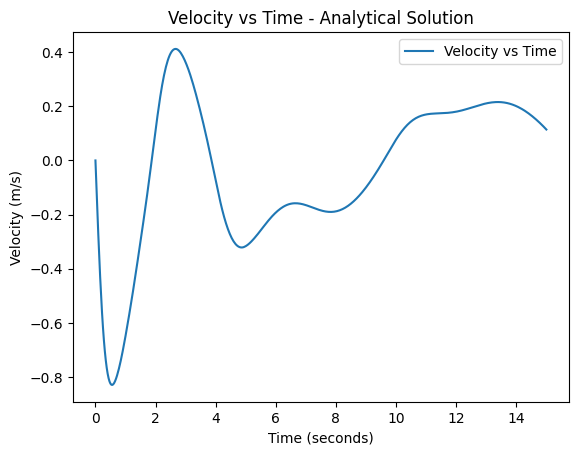

In [7]:
# Plot the velocity data
plt.plot(t_eval, velocities_anal, label='Velocity vs Time')
plt.xlabel('Time (seconds)')
plt.ylabel('Velocity (m/s)')
plt.title('Velocity vs Time - Analytical Solution')
plt.legend()
# Save the plot to a file
plt.savefig('figures/velocity_plot_analytical.png')
plt.show()

In [8]:
# Read the x and v data from all the files and store in a lists of list
# Define the file names
filenames = ["resultsq3/output_RK4_0.031250.txt", "resultsq3/output_RK4_0.062500.txt", "resultsq3/output_RK4_0.125000.txt","resultsq3/output_RK4_0.250000.txt","resultsq3/output_RK4_0.500000.txt"]
# Initialize lists to store displacement and velocity data
displacements_all = []
velocities_all = []
# Open the file and read the data
for filename in filenames:
    displacements = []
    velocities = []
    with open(filename, 'r') as file:
        # Skip the header line
        next(file)
        # Read the data line by line
        for line in file:
            # Split the line into components
            parts = line.split()
            # Extract the displacement and velocity values
            displacement = float(parts[1])
            velocity = float(parts[2])
            # Store the values in the respective lists
            displacements.append(displacement)
            velocities.append(velocity)
    # Store the values in the respective lists
    displacements_all.append(displacements)
    velocities_all.append(velocities)
    

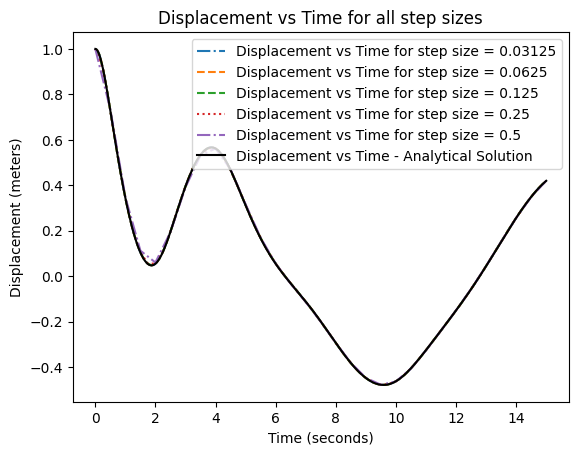

In [9]:
# create a list of linestyles
linestyles = ['-.', '--', '--', ':', '-.',(0, (3, 1, 1, 1))]
# Plot the displacement data for all step sizes
step_sizes = [0.03125, 0.0625, 0.125, 0.25, 0.50]
for i in range(len(filenames)):
    t = np.arange(0, 15+step_sizes[i], step_sizes[i])
    plt.plot(t, displacements_all[i], label='Displacement vs Time for step size = '+str(0.03125*(2**i)), linestyle=linestyles[i])
plt.plot(t_eval, displacements_anal, label='Displacement vs Time - Analytical Solution', linestyle='-', color='black') 
plt.xlabel('Time (seconds)')
plt.ylabel('Displacement (meters)')
plt.title('Displacement vs Time for all step sizes')
plt.legend()
# Save the plot to a file
plt.savefig('figures/displacement_plot_all.png')
plt.show()


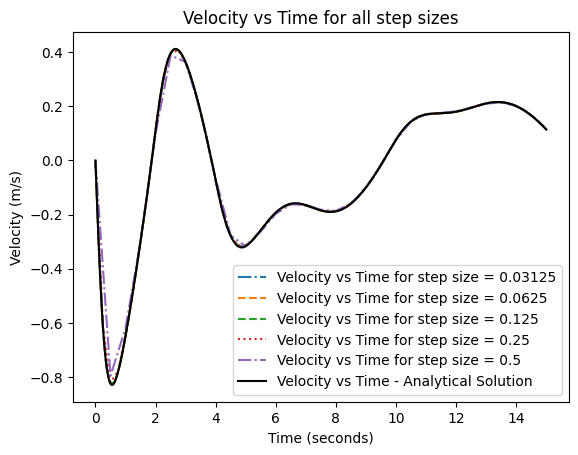

In [10]:
# Plot the velocity data for all step sizes
for i in range(len(filenames)):
    t = np.arange(0, 15+step_sizes[i], step_sizes[i])
    plt.plot(t, velocities_all[i], label='Velocity vs Time for step size = '+str(0.03125*(2**i)), linestyle=linestyles[i])
plt.plot(t_eval, velocities_anal, label='Velocity vs Time - Analytical Solution', linestyle='-', color='black')
plt.xlabel('Time (seconds)')
plt.ylabel('Velocity (m/s)')
plt.title('Velocity vs Time for all step sizes')
plt.legend()
# Save the plot to a file
plt.savefig('figures/velocity_plot_all.png')
plt.show()

In [11]:
# Read the data from the convergence file and store in a list
# Define the file name
filename = "resultsq3/output_RK4_convergence.txt"

# Initialize lists to store differences of displacements and velocities
displacement_differences = []
velocity_differences = []

# Open the file and read the data
with open(filename, 'r') as file:
    # Read the data line by line
    for line in file:
        # Check if the line contains displacement or velocity difference
        if "difference between displacements" in line:
            # Extract the displacement difference value
            parts = line.split()
            displacement_difference = float(parts[-1])
            # Store the value in the displacement differences list
            displacement_differences.append(displacement_difference)
        elif "difference between velocities" in line:
            # Extract the velocity difference value
            parts = line.split()
            velocity_difference = float(parts[-1])
            # Store the value in the velocity differences list
            velocity_differences.append(velocity_difference)

# # Print the lists to verify the data
# print("Displacement Differences:", displacement_differences)
# print("Velocity Differences:", velocity_differences)

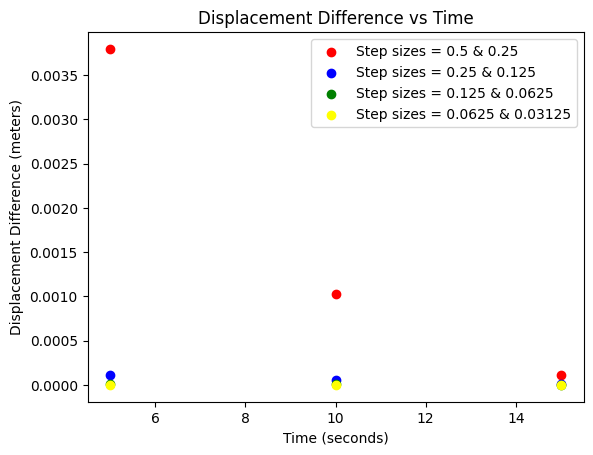

In [12]:

step_sizes = [0.50, 0.25, 0.125, 0.0625, 0.03125]
t = [5, 10, 15, 5, 10, 15, 5, 10, 15, 5, 10, 15]

# Use a set to keep track of added labels to avoid duplicates in the legend
added_labels = set()

for i in range(len(displacement_differences)):
    if i < 3:
        color = 'red'
        label = f'Step sizes = {step_sizes[0]} & {step_sizes[1]}'
    elif i < 6:
        color = 'blue'
        label = f'Step sizes = {step_sizes[1]} & {step_sizes[2]}'
    elif i < 9:
        color = 'green'
        label = f'Step sizes = {step_sizes[2]} & {step_sizes[3]}'
    else:
        color = 'yellow'
        label = f'Step sizes = {step_sizes[3]} & {step_sizes[4]}'
    
    # Add the scatter point
    if label not in added_labels:
        plt.scatter(t[i], displacement_differences[i], color=color, label=label)
        added_labels.add(label)
    else:
        plt.scatter(t[i], displacement_differences[i], color=color)
plt.xlabel('Time (seconds)')
plt.ylabel('Displacement Difference (meters)')
plt.title('Displacement Difference vs Time')
plt.legend()
# Save the plot to a file
plt.savefig('figures/displacement_difference_plot.png')
plt.show()

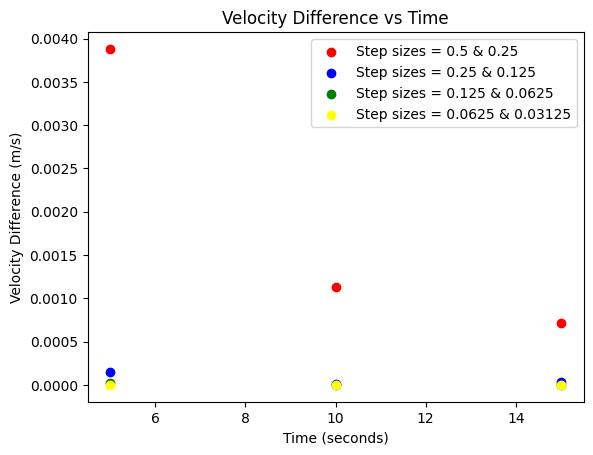

In [13]:
# Plot the velocity differences
added_labels = set()
for i in range(len(velocity_differences)):
    if i < 3:
        color = 'red'
        label = f'Step sizes = {step_sizes[0]} & {step_sizes[1]}'
    elif i < 6:
        color = 'blue'
        label = f'Step sizes = {step_sizes[1]} & {step_sizes[2]}'
    elif i < 9:
        color = 'green'
        label = f'Step sizes = {step_sizes[2]} & {step_sizes[3]}'
    else:
        color = 'yellow'
        label = f'Step sizes = {step_sizes[3]} & {step_sizes[4]}'
    
    # Add the scatter point
    if label not in added_labels:
        plt.scatter(t[i], velocity_differences[i], color=color, label=label)
        added_labels.add(label)
    else:
        plt.scatter(t[i], velocity_differences[i], color=color)
plt.xlabel('Time (seconds)')
plt.ylabel('Velocity Difference (m/s)')
plt.title('Velocity Difference vs Time')
plt.legend()
# Save the plot to a file
plt.savefig('figures/velocity_difference_plot.png')
plt.show()
